# ML Assignment 2 — Wine Quality Classification: Model Training

**Name:** Niraj Kumar Rai  
**BITS ID:** 2025ac05920  
**Course:** M.Tech (AIML)

This notebook implements and trains **5 classification models** on the Wine Quality (Red) dataset:
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (kNN)
4. Gaussian Naive Bayes
5. Random Forest (Ensemble)

For each model, the following evaluation metrics are computed:
- Accuracy, AUC, Precision, Recall, F1 Score, MCC

All trained models are saved as `.joblib` files in the `model/` directory.

## 1. Import Required Libraries

Import all necessary libraries for data handling, model training, evaluation, and serialization.

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Explore the Wine Quality Dataset

The dataset is the **Wine Quality (Red)** dataset from UCI/Kaggle.  
It contains 1599 instances with 11 physicochemical features and a quality score (0–10).

**Source:** https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

> Note: The CSV file uses semicolons (`;`) as the separator.

In [3]:
# Load the dataset (semicolon-separated)
df = pd.read_csv("../data/winequality-red.csv", sep=";")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Basic statistics
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


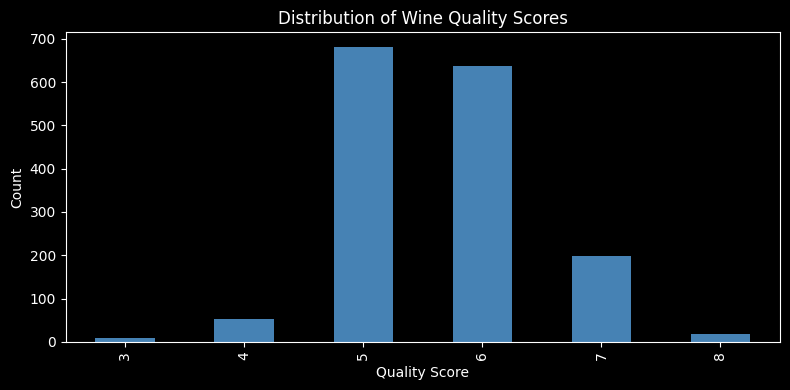

In [6]:
# Visualize the distribution of the original quality score
fig, ax = plt.subplots(figsize=(8, 4))
df["quality"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Count")
ax.set_title("Distribution of Wine Quality Scores")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Feature Engineering

We convert the multi-class quality score into a **binary classification** target:
- `quality >= 6` → **1 (good)**
- `quality < 6` → **0 (bad)**

This gives us a balanced binary classification problem.

In [7]:
# Create binary target: quality >= 6 is "good" (1), else "bad" (0)
df["target"] = (df["quality"] >= 6).astype(int)
df = df.drop(columns=["quality"])

print(f"Dataset shape after preprocessing: {df.shape}")
print(f"\nClass distribution:")
print(df["target"].value_counts())
print(f"\nClass proportions:")
print(df["target"].value_counts(normalize=True).round(4))

Dataset shape after preprocessing: (1599, 12)

Class distribution:
target
1    855
0    744
Name: count, dtype: int64

Class proportions:
target
1    0.5347
0    0.4653
Name: proportion, dtype: float64


## 4. Train-Test Split and Feature Scaling

We split the data into 80% training and 20% testing sets using stratified sampling to maintain class proportions.  
Feature scaling (StandardScaler) is applied for models that are distance-based or gradient-based (Logistic Regression, kNN).

In [8]:
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set: (1279, 11)
Testing set:  (320, 11)

Train class distribution:
target
1    684
0    595
Name: count, dtype: int64

Test class distribution:
target
1    171
0    149
Name: count, dtype: int64


In [9]:
# Scale features for distance-based / gradient-based models
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns, index=X_test.index
)

# Save the scaler for use in the Streamlit app
os.makedirs(".", exist_ok=True)
joblib.dump(scaler, "scaler.joblib")
print("Scaler saved to model/scaler.joblib")

# Save feature names
with open("features.json", "w") as f:
    json.dump(list(X.columns), f)
print("Feature names saved to model/features.json")

Scaler saved to model/scaler.joblib
Feature names saved to model/features.json


In [10]:
# Save the test data for use in the Streamlit app
test_df = X_test.copy()
test_df["target"] = y_test
test_df.to_csv("../test_data.csv", index=False)
print(f"Test data saved to test_data.csv ({len(test_df)} rows)")

Test data saved to test_data.csv (320 rows)


## 5. Model 1: Logistic Regression

A linear model for binary classification. Uses scaled features for better convergence.

In [11]:
# Train Logistic Regression (uses scaled features)
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — Predictions made.")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")

Logistic Regression — Predictions made.
Confusion Matrix:
[[111  38]
 [ 45 126]]


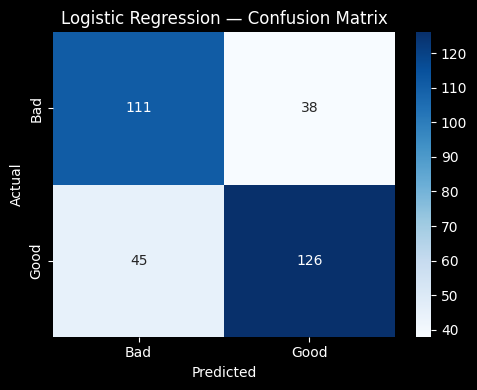

In [20]:
# Confusion matrix visualization — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. Model 2: Decision Tree Classifier

A non-linear model that splits data by feature thresholds. `max_depth=5` prevents overfitting.

In [12]:
# Train Decision Tree (uses unscaled features)
dtree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dtree.fit(X_train, y_train)

y_pred_dt = dtree.predict(X_test)
y_proba_dt = dtree.predict_proba(X_test)[:, 1]

print("Decision Tree — Predictions made.")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_dt)}")

Decision Tree — Predictions made.
Confusion Matrix:
[[108  41]
 [ 45 126]]


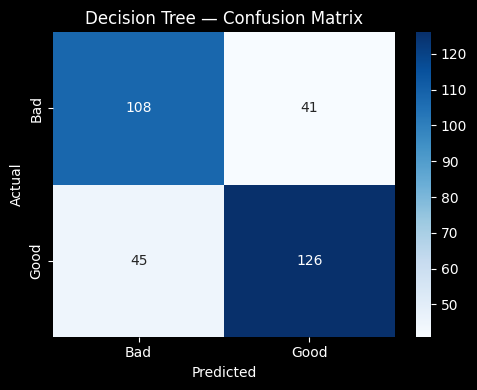

In [21]:
# Confusion matrix visualization — Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=ax)
ax.set_title("Decision Tree — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 7. Model 3: K-Nearest Neighbors (kNN)

An instance-based classifier. Uses `k=5` neighbors and scaled features (distance-based).

In [13]:
# Train kNN (uses scaled features)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("kNN — Predictions made.")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")

kNN — Predictions made.
Confusion Matrix:
[[108  41]
 [ 42 129]]


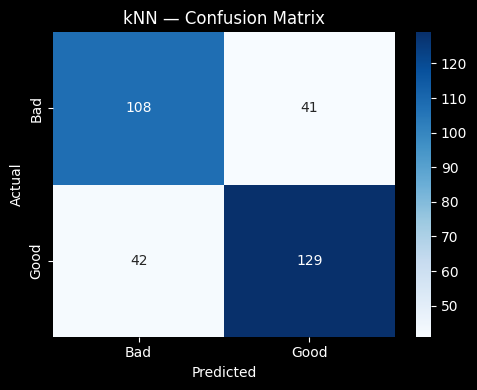

In [22]:
# Confusion matrix visualization — kNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=ax)
ax.set_title("kNN — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Model 4: Gaussian Naive Bayes

A probabilistic classifier based on Bayes' theorem. Assumes feature independence. No scaling needed.

In [14]:
# Train Gaussian Naive Bayes (uses unscaled features)
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

print("Naive Bayes — Predictions made.")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_nb)}")

Naive Bayes — Predictions made.
Confusion Matrix:
[[116  33]
 [ 55 116]]


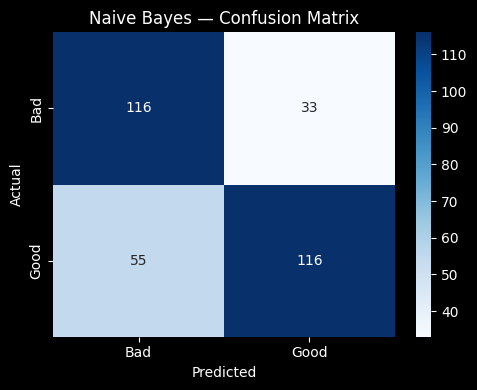

In [23]:
# Confusion matrix visualization — Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=ax)
ax.set_title("Naive Bayes — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Model 5: Random Forest (Ensemble)

An ensemble of 100 decision trees. Typically the strongest performer on tabular data. No scaling needed.

In [15]:
# Train Random Forest (uses unscaled features)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Predictions made.")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

Random Forest — Predictions made.
Confusion Matrix:
[[122  27]
 [ 35 136]]


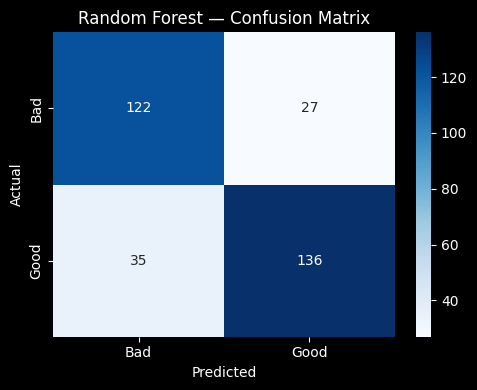

In [24]:
# Confusion matrix visualization — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"], ax=ax)
ax.set_title("Random Forest — Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 10. Evaluate Model Performance

Compute the following metrics for each model:
- **Accuracy** — overall correctness
- **AUC** — area under the ROC curve (threshold-independent)
- **Precision** — of predicted positives, how many are real
- **Recall** — of actual positives, how many we found
- **F1 Score** — harmonic mean of precision and recall
- **MCC** — Matthews Correlation Coefficient (robust to imbalance)

In [16]:
# Collect all models and their predictions
models_results = {
    "Logistic Regression": (y_pred_lr, y_proba_lr),
    "Decision Tree": (y_pred_dt, y_proba_dt),
    "kNN": (y_pred_knn, y_proba_knn),
    "Naive Bayes": (y_pred_nb, y_proba_nb),
    "Random Forest": (y_pred_rf, y_proba_rf),
}

# Compute metrics for each model
results = {}
for name, (y_pred, y_proba) in models_results.items():
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    }

# Display comparison table
print("=" * 85)
print(f"{'Model':<22} {'Accuracy':<10} {'AUC':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'MCC':<10}")
print("-" * 85)
for name, m in results.items():
    print(f"{name:<22} {m['Accuracy']:<10} {m['AUC']:<10} {m['Precision']:<10} {m['Recall']:<10} {m['F1']:<10} {m['MCC']:<10}")
print("=" * 85)

# Find the best model by F1
winner = max(results, key=lambda k: results[k]["F1"])
print(f"\nOverall Winner (by F1): {winner}")

Model                  Accuracy   AUC        Precision  Recall     F1         MCC       
-------------------------------------------------------------------------------------
Logistic Regression    0.7406     0.8242     0.7683     0.7368     0.7522     0.4808    
Decision Tree          0.7312     0.783      0.7545     0.7368     0.7456     0.461     
kNN                    0.7406     0.8117     0.7588     0.7544     0.7566     0.479     
Naive Bayes            0.725      0.7909     0.7785     0.6784     0.725      0.4569    
Random Forest          0.8063     0.9018     0.8344     0.7953     0.8144     0.6128    

Overall Winner (by F1): Random Forest


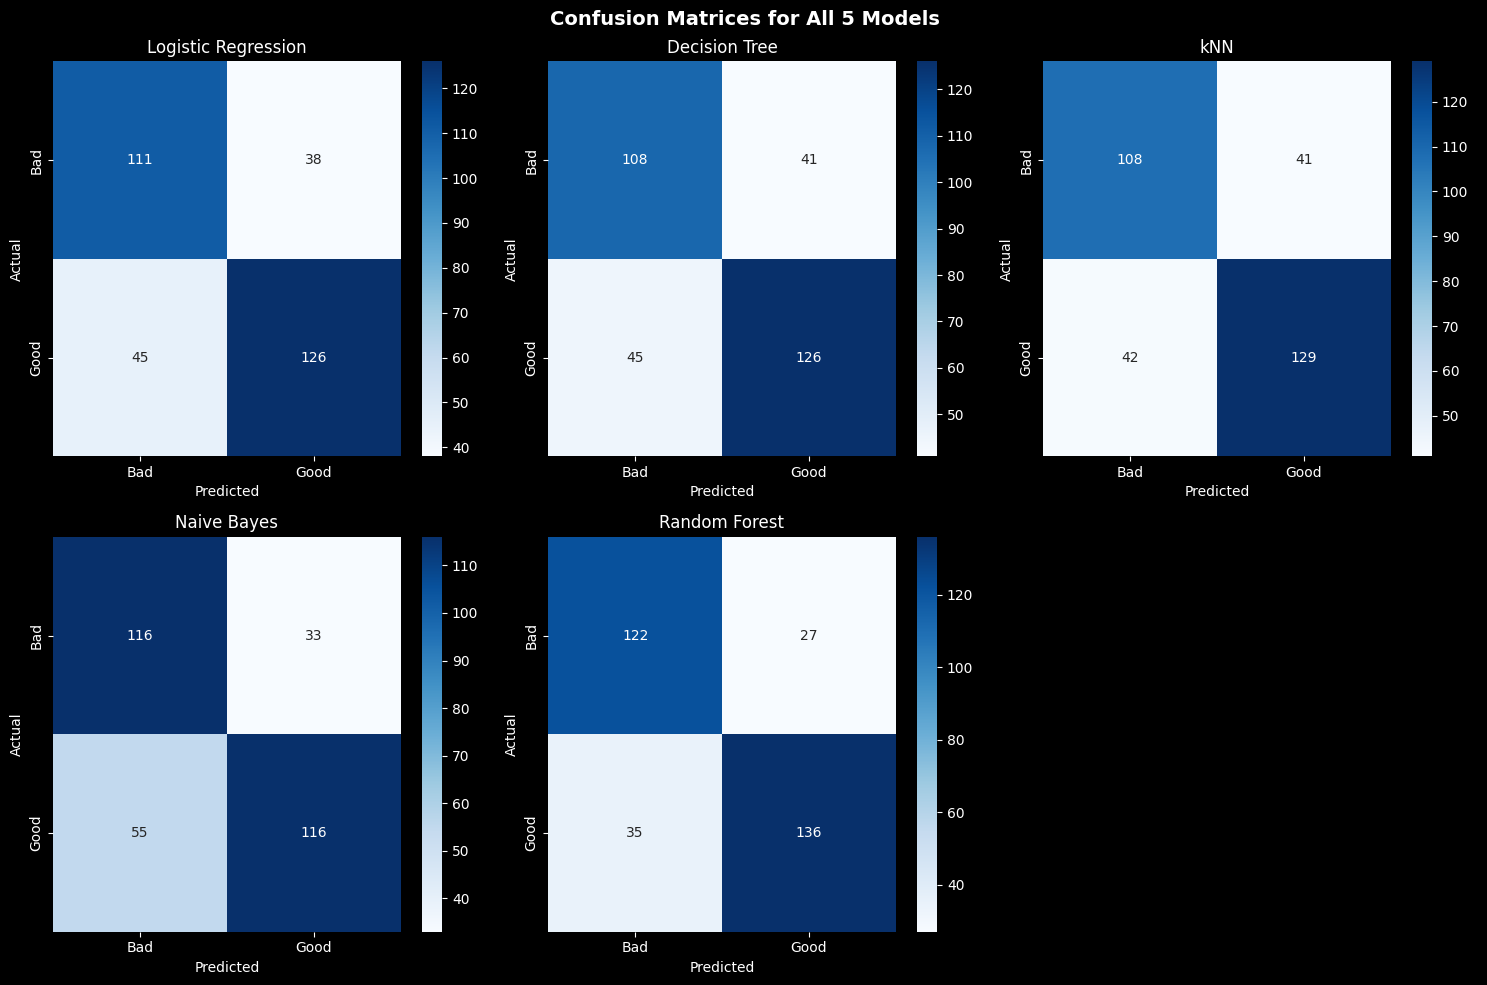

In [17]:
# Plot confusion matrices for all 5 models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Bad", "Good"], yticklabels=["Bad", "Good"],
                ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide the last empty subplot
axes[5].axis("off")
plt.suptitle("Confusion Matrices for All 5 Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# Print detailed classification report for each model
for name, (y_pred, _) in models_results.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Bad", "Good"]))


  Logistic Regression
              precision    recall  f1-score   support

         Bad       0.71      0.74      0.73       149
        Good       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320


  Decision Tree
              precision    recall  f1-score   support

         Bad       0.71      0.72      0.72       149
        Good       0.75      0.74      0.75       171

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320


  kNN
              precision    recall  f1-score   support

         Bad       0.72      0.72      0.72       149
        Good       0.76      0.75      0.76       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74    

## 11. Save Trained Models to the `model/` Directory

All 5 trained models are saved as `.joblib` files using `joblib` (efficient for NumPy arrays).  
The scaler and metrics are also saved for use by the Streamlit app.

In [19]:
# Save all 5 models as .joblib files
models_to_save = {
    "logistic_regression.joblib": log_reg,
    "decision_tree.joblib": dtree,
    "knn.joblib": knn,
    "naive_bayes.joblib": nb,
    "random_forest.joblib": rf,
}

for filename, model in models_to_save.items():
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# Save metrics to JSON
with open("metrics.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved: metrics.json")

print("\nAll models and artifacts saved to the model/ directory.")

Saved: logistic_regression.joblib
Saved: decision_tree.joblib
Saved: knn.joblib
Saved: naive_bayes.joblib
Saved: random_forest.joblib

Saved: metrics.json

All models and artifacts saved to the model/ directory.
